# HR Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
hr = pd.read_csv('HRDataset_v14.csv')
hr.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Question 1: Calcuating age of employees
### 1-1: Calculate age of employees using DOB column.

In [6]:
#age of employees
hr['DOB'].head()

0    07/10/83
1    05/05/75
2    09/19/88
3    09/27/88
4    09/08/89
Name: DOB, dtype: str

In [9]:
hr['DOB'] = pd.to_datetime(hr['DOB'])
now = pd.Timestamp.now()
hr['Age'] = ((now - hr['DOB']).dt.days / 365.25).astype(int)
hr['Age'].head()

0    43
1   -48
2    37
3    37
4    36
Name: Age, dtype: int64

In [ ]:
#cannot have negative age! 
print(hr['DOB'].head(10))
print(hr['DOB'].dtype)
print(pd.Timestamp.now())

0   1983-07-10
1   2075-05-05
2   1988-09-19
3   1988-09-27
4   1989-09-08
5   1977-05-22
6   1979-05-24
7   1983-02-18
8   2070-02-11
9   1988-01-07
Name: DOB, dtype: datetime64[us]
datetime64[us]
2026-08-16 16:28:47.819363


In [ ]:
#2075 was meant to be 1975. So we find and then convert the futuer dates as bellow:
hr[hr['DOB'] > pd.Timestamp.now()][['DOB']] 

,DOB
1,2075-05-05
8,2070-02-11
10,2074-01-12
11,2074-02-21
16,2066-04-17
...,...
290,2068-10-10
296,2055-11-14
301,2065-09-09
303,2069-10-02


In [14]:
future = hr['DOB'] > pd.Timestamp.now()

hr.loc[future, 'DOB'] = hr.loc[future, 'DOB'] - pd.DateOffset(years=100)
hr['DOB'].head(10)

0   1983-07-10
1   1975-05-05
2   1988-09-19
3   1988-09-27
4   1989-09-08
5   1977-05-22
6   1979-05-24
7   1983-02-18
8   1970-02-11
9   1988-01-07
Name: DOB, dtype: datetime64[us]

In [15]:
hr['DOB'] = pd.to_datetime(hr['DOB'])
now = pd.Timestamp.now()
hr['Age'] = ((now - hr['DOB']).dt.days / 365.25).astype(int)
hr['Age'].head()

0    43
1    51
2    37
3    37
4    36
Name: Age, dtype: int64

### 1-2: Divide people into 4 groups:
- Under 25  
- 25 to 40  
- 40 to 60  
- Over 60

In [ ]:
group_1 = hr.loc[hr["Age"].lt(25)]
group_2 = hr.loc[hr["Age"].ge(25) & hr["Age"].lt(40)]
group_3 = hr.loc[hr["Age"].ge(40) & hr["Age"].lt(60)]
group_4 = hr.loc[hr["Age"].ge(60)]

### 1-3: How many employees does each of the groups have?

In [28]:
print("Under 25:", len(group_1))
print("25 to 40:", len(group_2))
print("40 to 60:", len(group_3))
print("Over 60:", len(group_4))

Under 25: 0
25 to 40: 88
40 to 60: 215
Over 60: 25


## Question 2: Absences and Salary
### 2-1: Which position has the highest mean number of absences? Make a bar plot and explain.

In [33]:
hr.loc[ : , ['Absences', 'Position']]

,Absences,Position
0,1,Production Technician I
1,17,Sr. DBA
2,3,Production Technician II
3,15,Production Technician I
4,2,Production Technician I
...,...,...
306,13,Production Technician II
307,4,Production Technician I
308,16,CIO
309,11,Data Analyst


In [3]:
#postitions with highest mean of abcences 
mean_of_absences = hr.groupby('Position')['Absences'].mean().sort_values(ascending=False)
mean_of_absences

Position
Shared Services Manager         20.000000
Director of Sales               19.000000
Data Architect                  17.000000
CIO                             16.000000
IT Director                     15.000000
Director of Operations          15.000000
IT Manager - Infra              13.000000
Data Analyst                    12.571429
IT Support                      12.375000
Senior BI Developer             12.000000
Principal Data Architect        12.000000
Sr. DBA                         12.000000
BI Developer                    11.750000
Area Sales Manager              11.592593
IT Manager - DB                 10.500000
Production Technician II        10.263158
Production Technician I         10.218978
Sr. Network Engineer            10.200000
President & CEO                 10.000000
Software Engineer                9.200000
Sales Manager                    8.666667
Accountant I                     8.666667
Production Manager               8.571429
Administrative Assistant 

In [151]:
print(f"The position '{mean_of_absences.idxmax()}' has the highest mean number of abcences: {mean_of_absences.max()}")


The position 'Shared Services Manager' has the highest mean number of abcences: 20.0


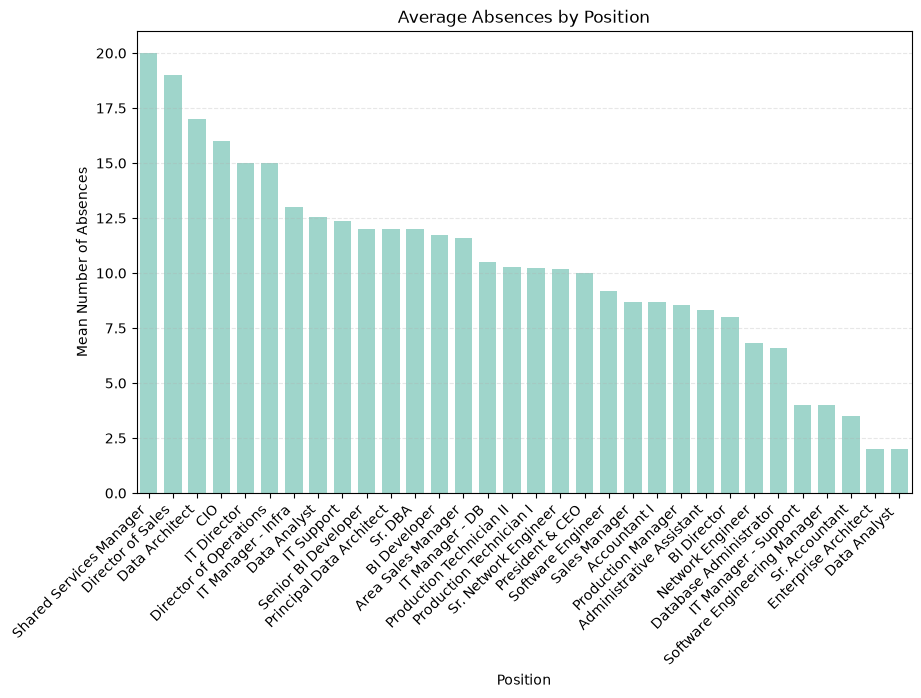

In [4]:
plt.figure(figsize=(10, 6))

sns.barplot(y=mean_of_absences.values,
            x=mean_of_absences.index, 
            color='#96DED1',
            width=0.8,
            gap=0.1,
            
            )

plt.title('Average Absences by Position')
plt.xlabel('Position')
plt.ylabel('Mean Number of Absences')
plt.xticks(rotation=45, ha='right')
plt.grid(axis ='y', linestyle = '--', alpha = 0.3)

The postion with the highest mean of absences is "Shared Services Manager" with 20 absences on average followed by "Director of Sales" and "Data Architect". Most of the positions have been absent on average for 7.5 to 12.5 days. The "Enterprise Architect" position has the lowest average amount of absences (around 2).

### 2-2: Which position has the highest mean amount of salary?

In [5]:
salary = hr.loc[ : , 'Salary']
hr.loc[ : , ['Position', 'Salary']]

,Position,Salary
0,Production Technician I,62506
1,Sr. DBA,104437
2,Production Technician II,64955
3,Production Technician I,64991
4,Production Technician I,50825
...,...,...
306,Production Technician II,65893
307,Production Technician I,48513
308,CIO,220450
309,Data Analyst,89292


In [6]:
#postitions with highest mean of salary 
mean_of_salary = hr.groupby('Position')['Salary'].mean().sort_values(ascending=False)
mean_of_salary

Position
President & CEO                 250000.000000
CIO                             220450.000000
Director of Sales               180000.000000
IT Director                     178000.000000
Director of Operations          170500.000000
IT Manager - Infra              157000.000000
Data Architect                  150290.000000
IT Manager - DB                 144959.500000
IT Manager - Support            138888.000000
Principal Data Architect        120000.000000
BI Director                     110929.000000
Database Administrator          108499.600000
Enterprise Architect            103613.000000
Sr. Accountant                  102859.000000
Sr. DBA                         102234.000000
Software Engineer                96719.200000
BI Developer                     95465.000000
Sr. Network Engineer             93070.800000
Shared Services Manager          93046.000000
Data Analyst                     89932.571429
Data Analyst                     88527.000000
Senior BI Developer      

In [7]:
print(f"The position '{mean_of_salary.idxmax()}' has the highest mean amount of salary: {mean_of_salary.max()}")


The position 'President & CEO' has the highest mean amount of salary: 250000.0


### 2-3: Analyze employee salaries using a histogram figure (by activating kde). Explain your analysis. 

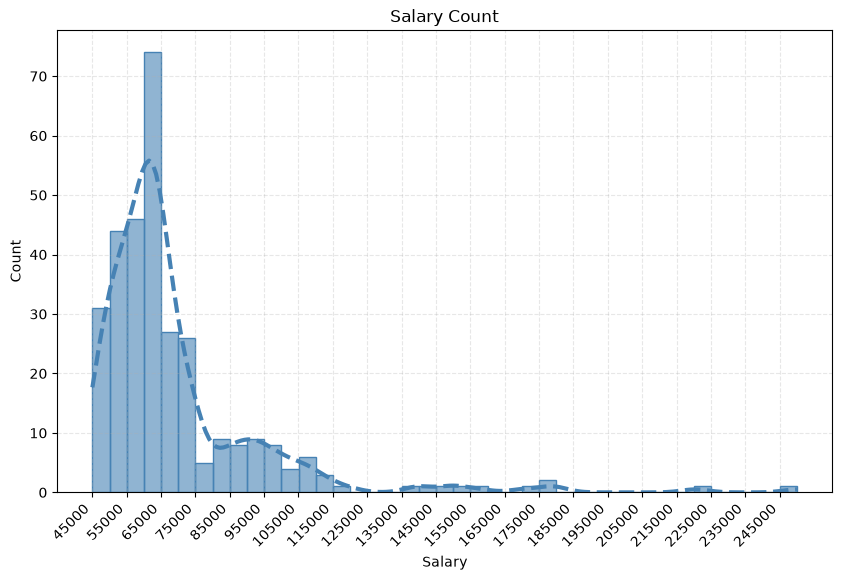

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(data=hr, x ='Salary', kde =True,
    bins=40,
    alpha=0.6,
    color='steelblue',
    edgecolor='steelblue',
    stat='count',
    binwidth=5000,
    kde_kws={'bw_adjust': 0.5}, 
    line_kws={
        'linewidth': 3,
        'linestyle': '--',
        'alpha': 1
    })

plt.title('Salary Count')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.xticks(range(45000, int(hr['Salary'].max()) + 5000, 10000), rotation=45, ha='right')
plt.grid(linestyle = '--', alpha = 0.3)

In [9]:
counts, bin_edges = np.histogram(salary, bins=40)
print(counts)

[31 45 50 71 31 22  4  8  9 10  8  5  4  2  1  0  0  0  2  0  2  1  0  0
  1  1  1  0  0  0  0  0  0  0  1  0  0  0  0  1]


In [10]:
salary_bins = pd.DataFrame({
    'Salary Range': [
        f'{bin_edges[i]:,.0f} - {bin_edges[i+1]:,.0f}'
        for i in range(len(counts))
    ],
    'Number of Employees': counts,
    'Percentage of Employees' : (counts/counts.sum()*100).round(2).astype(str) + '%'
})

salary_bins

,Salary Range,Number of Employees,Percentage of Employees
0,"45,046 - 50,170",31,9.97%
1,"50,170 - 55,294",45,14.47%
2,"55,294 - 60,418",50,16.08%
3,"60,418 - 65,541",71,22.83%
4,"65,541 - 70,665",31,9.97%
5,"70,665 - 75,789",22,7.07%
6,"75,789 - 80,913",4,1.29%
7,"80,913 - 86,037",8,2.57%
8,"86,037 - 91,161",9,2.89%
9,"91,161 - 96,284",10,3.22%


The data shows that the vast majority of employees earn between 45,000$ and 75,000$. 31 employees fall within the lowest salary range and the number rises up to the salary range 60,000$-65,000$. This range, with 71 employees has the highest amount, accounting for around 23% of the total staff. Only a small percentage of people earn more than 110000$. Lastly, the highest paid employee earns an amount between 245000$ and 250000$. The distribuition is positively skewed beacuse a large number of people earn less than a few employees. 

## Question 3: Employee turnover rate
### 3-1: What percentage of employees have left the company

In [11]:
hr.loc[ : , ['DateofTermination']]

,DateofTermination
0,NaN
1,6/16/2016
2,9/24/2012
3,NaN
4,9/6/2016
...,...
306,NaN
307,9/29/2015
308,NaN
309,NaN


In [12]:
terminated_employees = hr['DateofTermination'].notna().sum() #or hr['DateofTermination'].count()
all_employees = len(hr['DateofTermination'])
turnover_rate = (terminated_employees / all_employees) * 100
print(f' {turnover_rate:.2f}% of employees have left the company')

 33.44% of employees have left the company


### 3-2: Is the rate of turnover higher for single employees than for married employees?

In [13]:
hr.loc[ : , ['MaritalDesc', 'MarriedID', 'DateofTermination']]

,MaritalDesc,MarriedID,DateofTermination
0,Single,0,NaN
1,Married,1,6/16/2016
2,Married,1,9/24/2012
3,Married,1,NaN
4,Divorced,0,9/6/2016
...,...,...,...
306,Single,0,NaN
307,Single,0,9/29/2015
308,Single,0,NaN
309,Single,0,NaN


In [14]:
#married
married_and_terminated = (hr['DateofTermination'].notna() & (hr['MarriedID'] == 1)).sum()
total_married = (hr['MarriedID'] == 1).sum()
married_turnover_rate = (married_and_terminated / total_married) * 100
print(f' {married_turnover_rate:.2f}% of married employees have left the company')

 37.90% of married employees have left the company


In [15]:
#not married (single, divorced, widowed)
single_and_terminated = (hr['DateofTermination'].notna() & (hr['MarriedID'] == 0)).sum()
total_single = (hr['MarriedID'] == 0).sum()
single_turnover_rate = (single_and_terminated / total_single) * 100
print(f' {single_turnover_rate:.2f}% of single employees have left the company')

 30.48% of single employees have left the company


The turnover rate for married employees is higher than that of single employees. 

## Question 4: Date of hire and date of termination analysis
### 4-1: How long have the terminated employees stayed in the company on average?

In [16]:
hr.loc[ : , ['DateofHire', 'DateofTermination']]

,DateofHire,DateofTermination
0,7/5/2011,NaN
1,3/30/2015,6/16/2016
2,7/5/2011,9/24/2012
3,1/7/2008,NaN
4,7/11/2011,9/6/2016
...,...,...
306,7/7/2014,NaN
307,9/2/2008,9/29/2015
308,4/10/2010,NaN
309,3/30/2015,NaN


In [17]:
#calculating the employment duration in years
hr['DateofTermination'] = pd.to_datetime(hr['DateofTermination'])
hr['DateofHire'] = pd.to_datetime(hr['DateofHire'])
hr['EmploymentDuration'] = ((hr['DateofTermination'] - hr['DateofHire']).dt.days/ 365.25)
hr.loc[ : , ['DateofHire', 'DateofTermination', 'EmploymentDuration']]

,DateofHire,DateofTermination,EmploymentDuration
0,2011-07-05,NaT,NaN
1,2015-03-30,2016-06-16,1.215606
2,2011-07-05,2012-09-24,1.223819
3,2008-01-07,NaT,NaN
4,2011-07-11,2016-09-06,5.158111
...,...,...,...
306,2014-07-07,NaT,NaN
307,2008-09-02,2015-09-29,7.071869
308,2010-04-10,NaT,NaN
309,2015-03-30,NaT,NaN


In [18]:
#calculating the average duration
sum_of_duration = hr['EmploymentDuration'].sum()
average_of_duration = hr['EmploymentDuration'].mean()
print(f"The average years spent in the company by terminated employees is {average_of_duration}")

The average years spent in the company by terminated employees is 3.4611172537250567


### 4-2: In which year does the company have the most hires?

In [19]:
number_of_hires = hr['DateofHire'].dt.year.value_counts().sort_index()
number_of_hires

DateofHire
2006     1
2007     2
2008     3
2009     7
2010     9
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14
2017     6
2018     1
Name: count, dtype: int64

In [20]:
max_hirings_year = number_of_hires.idxmax()
print(f"The year {max_hirings_year} has the most hirings: {number_of_hires.max()}")

The year 2011 has the most hirings: 83


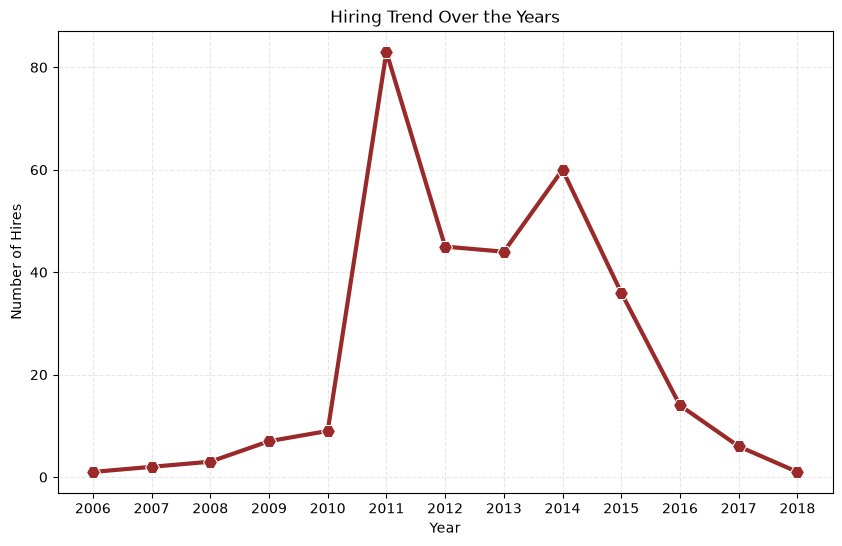

In [21]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=number_of_hires.index,y=number_of_hires.values,
    marker='H',
    markersize=10,
    color='#9A2A2A',
    linewidth=3
)

plt.title('Hiring Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Hires')
plt.xticks(number_of_hires.index)
plt.grid(linestyle='--', alpha=0.3)

plt.show()

The hiring trend is upward from 2006 to 2010 starting from 0 hires, followed by a sharp increase in 2011 with over 80 hires. After which, the number of hires decreases, with another increase in 2014 to 60 hires and then continues to decline to about 0 in 2018. 

## Question 5: Employee satisfaction and termination reason analysis
### 5-1: Compare the satisfaction of terminated employees with non-terminated employees. Is there a huge gap?

In [22]:
hr.loc[:, ['EmpSatisfaction', 'TermReason', 'DateofTermination']]

,EmpSatisfaction,TermReason,DateofTermination
0,5,N/A-StillEmployed,NaT
1,3,career change,2016-06-16
2,3,hours,2012-09-24
3,5,N/A-StillEmployed,NaT
4,4,return to school,2016-09-06
...,...,...,...
306,4,N/A-StillEmployed,NaT
307,2,Another position,2015-09-29
308,5,N/A-StillEmployed,NaT
309,3,N/A-StillEmployed,NaT


In [23]:
terminated_satisfaction = hr.loc[hr['DateofTermination'].notna(),'EmpSatisfaction']
terminated_satisfaction_average = terminated_satisfaction.mean()
terminated_satisfaction_average
print(f"The average satisfaction reported by terminated employees is {terminated_satisfaction_average:.2f}")

The average satisfaction reported by terminated employees is 3.88


In [24]:
current_employees_satisfaction = hr.loc[hr['DateofTermination'].isna(),'EmpSatisfaction']
current_employees_satisfaction_average = current_employees_satisfaction.mean()
current_employees_satisfaction_average
print(f"The average satisfaction reported by current employees is {current_employees_satisfaction_average:.2f}")

The average satisfaction reported by current employees is 3.89


In [25]:
terminated_employees = hr['DateofTermination'].notna()
current_employees = hr['DateofTermination'].isna()

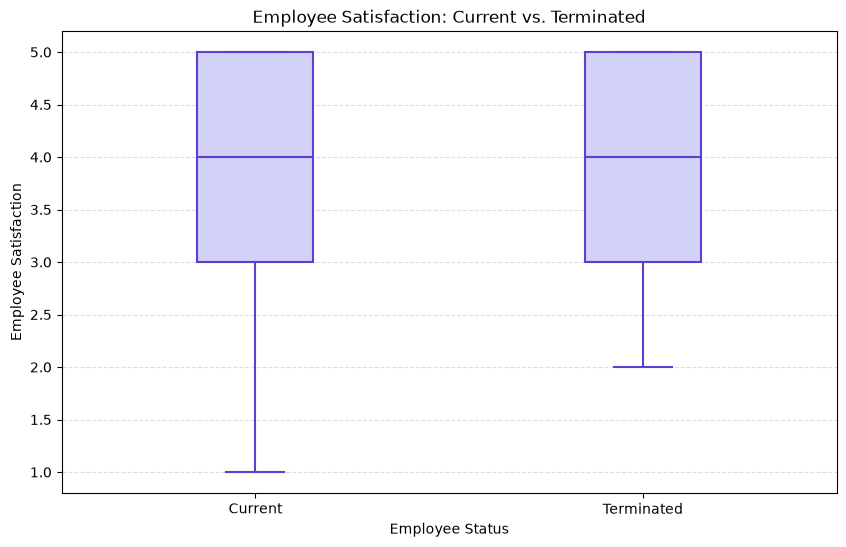

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=np.where(terminated_employees, 'Terminated', 'Current'), y=hr['EmpSatisfaction'],
            color='#CCCCFF',
            linecolor='#5D3FD3',
            linewidth=1.5,
            width=0.3,
            #whis=(2, 5)
            )

plt.xlabel('Employee Status')
plt.ylabel('Employee Satisfaction')
plt.title('Employee Satisfaction: Current vs. Terminated')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

The employee satidfaction if very similar among current and terminated employess. The 25th percentile, median and maximum amount for both current and terminated employees are the same, with numbers 3, 4 and 5 respectively. Also note that the maximum amount and the 75th percentile are the same in both categories. The only difference is the minimum amount which is 1 for the current employees and 2 for the terminated employees (this difference is because of 1 employee).

The satisfaction levels of current and terminated employees are very similar and the difference is only 0.01.

### 5-2: Analyze reasons of termination. What are the top 5 most common reasons?

In [27]:
terminated = hr.loc[hr['DateofTermination'].notna()]
termination_reasons = terminated['TermReason'].value_counts().sort_values(ascending=False)
termination_reasons

TermReason
Another position                    20
unhappy                             14
more money                          11
career change                        9
hours                                8
attendance                           7
return to school                     5
relocation out of area               5
performance                          4
retiring                             4
military                             4
no-call, no-show                     4
maternity leave - did not return     3
medical issues                       3
Learned that he is a gangster        1
Fatal attraction                     1
gross misconduct                     1
Name: count, dtype: int64

In [28]:
termination_reasons.head(5)

TermReason
Another position    20
unhappy             14
more money          11
career change        9
hours                8
Name: count, dtype: int64

The most common reason for termination is position, reported by 20 employees. The following reason reported by 14 employees is being unhappy. After that, 11 employees left the company to earn more money. The fourth and fifth reasons are career change and hours reported by 9 and 8 employees respectively. As you can see the top reason has the most frequency by far which is about 1.4 times the second in rank.  

### 5-3: Is there a direct relationship between the number of special projects and the number of absences? Graph a scatter plot and the correlation. 

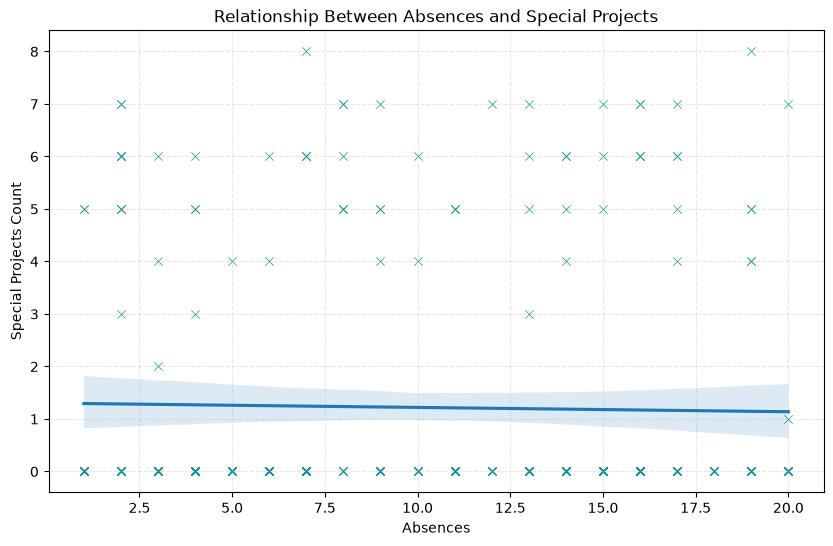

In [29]:
size='Absences'

plt.figure(figsize=(10, 6))

sns.scatterplot(data=hr, x='Absences', y='SpecialProjectsCount',
                color='#088F8F',
                marker='x'
                )
sns.regplot(data=hr, x='Absences', y='SpecialProjectsCount', scatter=False)

plt.xlabel('Absences')
plt.ylabel('Special Projects Count')
plt.title('Relationship Between Absences and Special Projects')
plt.grid(linestyle='--', alpha=0.3)

plt.show()

In [30]:
correlation = hr['Absences'].corr(hr['SpecialProjectsCount'])

print(f'Correlation: {correlation:.2f}')

Correlation: -0.02


There is no meaninful relationship between the two variables. The correlation between them is -0.02 which is very close to zero. The negative sign indicates a negative linear correlation (though negligible). The graph is scattered and does not display and order. Therefore the regression line is almost flat, suggesting that there is no meaningful relationshop between absences and the number of special projects. 